## Extract Diagnosis from the parent siblings questionnaire

In [1]:
# Import modules

import os
import pandas as pd
from pathlib import Path
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
#import missingno as msno
import unicodedata
import re
from difflib import SequenceMatcher

In [2]:
## Import all csv demo files 
demo_files = glob.glob(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/demographics_redcap/*/*FAMILY*.csv')
demo_df= pd.read_csv(demo_files[0])

In [3]:
demo_df.columns

Index(['record_id', 'redcap_event_name', 'redcap_repeat_instrument',
       'redcap_repeat_instance', 'q1k_proband_id_1', 'q1k_disorderdiag_1',
       'q1k_relative_idgenerated_1', 'cfq_diag_asd', 'q1k_rel_proband_id',
       'enr2_pro_dob', 'enr2_pro_rel_prob_2', 'enr2_pro_prob_fname',
       'enr2_pro_prob_lname', 'cfq_part_name', 'cfq_sab_part',
       'cfq_diag_asd_part', 'cfq_diag_asd_par1', 'cfq_name_par1',
       'cfq_yob_par1', 'cfq_diag_asd_par2', 'cfq_sab_par2', 'cfq_yob_par2',
       'cfq_name_par2', 'cfq_diag_asd_par3', 'cfq_yob_par3', 'cfq_name_par3',
       'cfq_sab_par3', 'cfq_name_par4', 'cfq_yob_par4', 'cfq_sab_par4',
       'cfq_diag_asd_par4', 'cfq_name_sib1', 'cfq_yob_sib1', 'cfq_sab_sib1',
       'cfq_diag_asd_sib1', 'cfq_name_sib2', 'cfq_yob_sib2',
       'cfq_diag_asd_sib2', 'cfq_name_sib3', 'cfq_yob_sib3', 'cfq_sab_sib3',
       'cfq_diag_asd_sib3', 'cfq_diag_asd_sib4', 'cfq_name_sib4',
       'cfq_yob_sib4', 'cfq_sab_sib4', 'cfq_name_sib5', 'cfq_yob_sib5',
    

In [4]:
demo_df

,record_id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,q1k_proband_id_1,q1k_disorderdiag_1,q1k_relative_idgenerated_1,cfq_diag_asd,q1k_rel_proband_id,enr2_pro_dob,...,cfq_sab_sib2,cfq_sab_par1,enr2_pro_sex,ghf_asd,cfq_diag_id,cfq_diag_fasd,cfq_diag_adhd,cfq_diag_ld,cfq_diag_lcd,cfq_diag_md
0,2,intake_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,questionnaires_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,eeget_visit_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,mri_visit_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,retest_eeget_visit_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5446,TEST - SCORING,intake_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5447,TEST - SCORING,questionnaires_arm_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5448,TEST HILDA - HSJ,intake_arm_1,NaN,NaN,NaN,1.0,NaN,NaN,(Proband: ),1980-10-05,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5449,TEST HILDA - HSJ,questionnaires_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step #1: Create a list of each family member and which proband they belong to


In [5]:
fam_members = demo_df[['q1k_relative_idgenerated_1', 'q1k_rel_proband_id', 'q1k_proband_id_1','q1k_disorderdiag_1',
                       'enr2_pro_dob', 'enr2_pro_prob_fname', "cfq_diag_asd",'ghf_asd',
                       'cfq_diag_id', 'cfq_diag_fasd',
       'cfq_diag_adhd', 'cfq_diag_ld', 'cfq_diag_lcd', 'cfq_diag_md',
                       
                       
                       'record_id']].drop_duplicates()
# Rename to q1k_ID and proband_id for clarity, dob and first name added
fam_members = fam_members.rename(columns={'q1k_relative_idgenerated_1': 'q1k_ID','q1k_disorderdiag_1':'ndd','q1k_rel_proband_id': 'proband_id',
                                          'enr2_pro_dob': 'dob', 'enr2_pro_prob_fname': 'first_name', 'cfq_diag_asd':"enrol_asd",
                                          'ghf_asd':"medical_records_asd", 
                                          
                                          'cfq_diag_id': 'intellectual_disability', 'cfq_diag_fasd': 'fetal_alcohol_syndrome', 
                                          'cfq_diag_adhd': 'adhd', 'cfq_diag_ld': 'learning_disability',
                                            'cfq_diag_lcd': 'language_communication_disorder', 'cfq_diag_md': 'motor_disorder'
                                          })

# Create separate datafrane with diagnosis from enrolment form
enrol_d=fam_members[['q1k_ID','record_id','q1k_proband_id_1', "enrol_asd",'ndd','medical_records_asd', 'adhd',
                     'learning_disability', 'language_communication_disorder', 'motor_disorder']].copy()

# Drop the record_id column as it's not needed
fam_members = fam_members.drop(columns=['record_id'])

# Change proband ID to string
fam_members['proband_id'] = fam_members['proband_id'].astype(str)


# Fix the formatting - extract Q1K ID from format like "(Proband: Q1K_HSJ_10040_P)"
# Using vectorized string operations for efficiency
fam_members['proband_id_clean'] = fam_members['proband_id'].str.extract(r'\(Proband:\s*(Q1K[^)]+)\)')

# Remove rows where proband_id couldn't be extracted (contains NaN) or q1k_ID is NaN
fam_members = fam_members.dropna(subset=['proband_id_clean', 'q1k_ID'])

# Keep the cleaned proband_id and drop the original
fam_members = fam_members.drop('proband_id', axis=1).rename(columns={'proband_id_clean': 'proband_id'})

# Add column for birth year 
fam_members['birth_year'] = pd.to_datetime(fam_members['dob'], errors='coerce').dt.year


In [6]:
enrol_d

,q1k_ID,record_id,q1k_proband_id_1,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder
0,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
5443,NaN,Q1K test - (for Irini),Q1K_MHC_2-Q1K test - (for Irini)_P,NaN,1.0,NaN,NaN,NaN,NaN,NaN
5444,NaN,Q1K test - (for Irini),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5446,NaN,TEST - SCORING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5448,NaN,TEST HILDA - HSJ,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [7]:
# Collapse columns based on record ID

enrol_d = enrol_d.groupby('record_id', as_index=False).first()  
enrol_d['q1k_ID'] = enrol_d['q1k_ID'].combine_first(enrol_d['q1k_proband_id_1'])

# Drop column q1k_proband_id_1 as it's no longer needed
enrol_d = enrol_d.drop(columns=['q1k_proband_id_1'])
# Drop missing q1k_ID rows
enrol_d = enrol_d.dropna(subset=['q1k_ID'])
enrol_d


,record_id,q1k_ID,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder
1,100,Q1K_HSJ_100100_P,1.0,1.0,1.0,0.0,1.0,1.0,0.0
2,101,Q1K_HSJ_100100_S1,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,102,Q1K_HSJ_100100_M1,0.0,1.0,NaN,1.0,0.0,0.0,0.0
4,103,Q1K_HSJ_100100_F1,0.0,1.0,0.0,1.0,1.0,0.0,0.0
5,104,Q1K_HSJ_100104_P,0.0,1.0,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...
1264,95,Q1K_HSJ_10093_O1,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1266,97,Q1K_HSJ_10097_P,1.0,1.0,1.0,0.0,1.0,1.0,0.0
1267,98,Q1K_HSJ_10097_M1,0.0,0.0,NaN,0.0,0.0,0.0,0.0
1268,99,Q1K_HSJ_10097_F1,NaN,0.0,NaN,NaN,NaN,NaN,NaN


## Step 2: Create list of proband and record id

In [8]:
# Select only proband ids and record ids
proband_records = demo_df[['q1k_proband_id_1', 'record_id']].drop_duplicates()
proband_records = proband_records.rename(columns={'q1k_proband_id_1': 'proband_id'})
# Drop those with NaN proband_id
proband_records = proband_records.dropna(subset=['proband_id'])
# Merge with fam_members to get record ids for each family member
fam_members = fam_members.merge(proband_records, on='proband_id', how='left')
fam_members



,q1k_ID,q1k_proband_id_1,ndd,dob,first_name,enrol_asd,medical_records_asd,intellectual_disability,fetal_alcohol_syndrome,adhd,learning_disability,language_communication_disorder,motor_disorder,proband_id,birth_year,record_id
0,Q1K_HSJ_10040_M1,NaN,0.0,1985-01-10,Mame Hélène,1.0,NaN,1.0,0.0,1.0,1.0,1.0,0.0,Q1K_HSJ_10040_P,1985.0,40
1,Q1K_HSJ_10043_M1,NaN,0.0,1964-06-10,Guylaine,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,Q1K_HSJ_10043_P,1964.0,43
2,Q1K_HSJ_10043_F1,NaN,0.0,1966-04-13,Yves,0.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,Q1K_HSJ_10043_P,1966.0,43
3,Q1K_HSJ_10046_S1,NaN,1.0,2015-09-28,James,1.0,NaN,0.0,0.0,1.0,0.0,1.0,0.0,Q1K_HSJ_10046_P,2015.0,46
4,Q1K_HSJ_10046_M1,NaN,0.0,1983-05-08,Audrey,0.0,NaN,0.0,0.0,1.0,0.0,0.0,0.0,Q1K_HSJ_10046_P,1983.0,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,Q1K_NIM_3530-3168_S3,NaN,1.0,2018-08-15,Amélie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3168_P,2018.0,530-3168
770,Q1K_NIM_3530-3168_S1,NaN,1.0,2012-09-27,Hugo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3168_P,2012.0,530-3168
771,Q1K_NIM_3530-3168_S2,NaN,0.0,2020-08-16,Mélodie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3168_P,2020.0,530-3168
772,Q1K_NIM_3530-3168_M1,NaN,0.0,1988-02-29,Mélanie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3168_P,1988.0,530-3168


### Step #3 create database of all siblings, their diagnoses, age, sex, birth year

In [9]:

def extract_family_members(demo_df):
    """
    Extract family member data from wide format to long format
    Creates one row per family member with their information
    """
    
    family_data = []
    
    # Define the family member types and their corresponding column patterns
    family_types = {
        'participant': 'part',  # The main participant 
        'parent1': 'par1',
        'parent2': 'par2', 
        'parent3': 'par3',
        'parent4': 'par4',
        'sibling1': 'sib1',
        'sibling2': 'sib2',
        'sibling3': 'sib3',
        'sibling4': 'sib4',
        'sibling5': 'sib5',
        'sibling6': 'sib6',
        'child1': 'child1',
        'child2': 'child2',
        'child3': 'child3',
        'child4': 'child4',
        'child5': 'child5',
        'child6': 'child6'
    }
    
    # Process each row in the demo_df
    for idx, row in demo_df.iterrows():
        record_id = row['record_id']
        
        # Extract data for each family member type
        for relationship, suffix in family_types.items():
            # Build column names for this family member
            name_col = f'cfq_name_{suffix}'
            yob_col = f'cfq_yob_{suffix}'
            sab_col = f'cfq_sab_{suffix}'
            diag_col = f'cfq_diag_asd_{suffix}'
            
            # Check if this family member has any data (at least name or year of birth)
            has_name = name_col in row and pd.notna(row[name_col]) and str(row[name_col]).strip() != ''
            has_yob = yob_col in row and pd.notna(row[yob_col])
            
            if has_name or has_yob:
                # Extract the data for this family member
                first_name = row[name_col] if name_col in row else np.nan
                birth_year = row[yob_col] if yob_col in row else np.nan
                sex = row[sab_col] if sab_col in row else np.nan
                asd_diagnosis = row[diag_col] if diag_col in row else np.nan
                
                # Add to family_data list
                family_data.append({
                    'first_name': first_name,
                    'record_id': record_id,
                    'birth_year': birth_year,
                    'sex': sex,
                    'relationship': relationship,
                    'asd_diagnosis': asd_diagnosis
                })
    
    # Convert to DataFrame
    family_df = pd.DataFrame(family_data)
    
    # Clean up the data
    # Remove rows where both name and birth_year are missing
    family_df = family_df.dropna(subset=['first_name', 'birth_year'], how='all')
    
    # Clean up sex values (convert to standard format)
    if 'sex' in family_df.columns:
        family_df['sex'] = family_df['sex'].replace({
            1: 'M', 
            2: 'F',
            '1': 'M',
            '2': 'F'
        })
    # Add NDD column
    
    
    # Clean up first names (remove extra whitespace)
    family_df['first_name'] = family_df['first_name'].astype(str).str.strip()
    family_df.loc[family_df['first_name'] == 'nan', 'first_name'] = np.nan
    
    return family_df

# Create the new family members dataframe
family_members_df = extract_family_members(demo_df)

In [10]:
family_members_df

,first_name,record_id,birth_year,sex,relationship,asd_diagnosis
0,Pierre,21,1950.0,F,parent1,0.0
1,Mireille,21,1950.0,M,parent2,0.0
2,Marc-Antoine,21,1977.0,F,sibling1,0.0
3,Rémi-David,21,1984.0,F,sibling2,0.0
4,Loik Jacob,21,2009.0,F,child1,1.0
...,...,...,...,...,...,...
1244,Jean-Claude,530-3175,1964.0,F,parent2,0.0
1245,Maxime,530-3175,2000.0,F,sibling1,0.0
1246,Léa,530-3175,2012.0,M,sibling2,NaN
1247,Mom,TEST HILDA - HSJ,1960.0,M,parent1,0.0


## Step 4: Family Member Q1K ID Matching with French Name Handling

Match family members from CFQ data with Q1K records to assign Q1K IDs to diagnosed family members. This step includes enhanced French name processing to handle accents, compound names, and name variations common in Quebec data.

In [11]:
def remove_accents(text):
    """Remove accents from French names"""
    if pd.isna(text):
        return ""
    nfkd_form = unicodedata.normalize('NFD', str(text))
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

def normalize_french_name(name):
    """Normalize French names for matching"""
    if pd.isna(name):
        return ""
    
    name = str(name).strip()
    name = remove_accents(name)
    name = name.lower()
    name = re.sub(r'[.\-_\']', ' ', name)
    name = re.sub(r'\s+', ' ', name)
    name = name.strip()
    
    return name

def extract_name_parts(name):
    """Extract individual name components for partial matching"""
    if pd.isna(name):
        return []
    
    normalized = normalize_french_name(name)
    parts = [part.strip() for part in normalized.split() if len(part.strip()) > 1]
    return parts

def french_name_similarity(name1, name2):
    """Calculate similarity for French names with partial matching"""
    if pd.isna(name1) or pd.isna(name2):
        return 0.0
    
    norm1 = normalize_french_name(name1)
    norm2 = normalize_french_name(name2)
    
    if norm1 == norm2:
        return 1.0
    
    parts1 = extract_name_parts(name1)
    parts2 = extract_name_parts(name2)
    
    if not parts1 or not parts2:
        return SequenceMatcher(None, norm1, norm2).ratio()
    
    matches = 0
    for part1 in parts1:
        for part2 in parts2:
            if part1 == part2 and len(part1) >= 3:
                matches += 1
                break
    
    partial_score = matches / max(len(parts1), len(parts2))
    full_similarity = SequenceMatcher(None, norm1, norm2).ratio()
    
    if partial_score > 0:
        combined_score = 0.6 * partial_score + 0.4 * full_similarity
    else:
        combined_score = full_similarity
    
    if norm1 in norm2 or norm2 in norm1:
        combined_score = max(combined_score, 0.8)
    
    return min(combined_score, 1.0)

In [12]:
def match_family_members_with_q1k(family_df, q1k_df):
    """
    Match family members with Q1K records using French name-aware matching
    """
    
    family_df = family_df.copy()
    q1k_df = q1k_df.copy()
    
    # Convert record_id to string for consistent matching
    family_df['record_id'] = family_df['record_id'].astype(str)
    q1k_df['record_id'] = q1k_df['record_id'].astype(str)
    
    matches = []
    
    print("Starting family member Q1K ID matching...")
    print(f"Family members to match: {len(family_df)}")
    print(f"Q1K records available: {len(q1k_df)}")
    print("=" * 60)
    
    for idx, fam_row in family_df.iterrows():
        if idx % 100 == 0:
            print(f"Processing record {idx}/{len(family_df)}")
            
        record_id = fam_row['record_id']
        first_name = fam_row['first_name']
        birth_year = fam_row['birth_year']
        sex = fam_row['sex']
        
        # Filter Q1K records by same family
        same_family = q1k_df[q1k_df['record_id'] == record_id]
        
        if len(same_family) == 0:
            match_result = {
                'q1k_ID': None,
                'match_type': 'no_family_match',
                'confidence': 'no_match',
                'name_score': 0.0,
                'birth_diff': None,
                'recommendation': 'REJECT'
            }
            matches.append({**fam_row.to_dict(), **match_result})
            continue
        
        best_match = None
        best_score = 0
        match_type = 'no_match'
        best_name_score = 0
        
        for _, q1k_row in same_family.iterrows():
            q1k_name = q1k_row['first_name']
            q1k_birth = q1k_row['birth_year']
            q1k_id = q1k_row['q1k_ID']
            
            # Infer sex from Q1K_ID
            q1k_sex = None
            if 'M' in q1k_id.split('_')[-1]:
                q1k_sex = 1.0
            elif 'F' in q1k_id.split('_')[-1]:
                q1k_sex = 2.0
            
            # Calculate French-aware name similarity
            name_score = french_name_similarity(first_name, q1k_name)
            
            # Calculate birth year difference
            birth_diff = abs(birth_year - q1k_birth) if pd.notna(birth_year) and pd.notna(q1k_birth) else float('inf')
            
            # Check sex match
            sex_match = (pd.isna(sex) or pd.isna(q1k_sex) or sex == q1k_sex)
            
            # Scoring system
            score = 0
            current_match_type = 'no_match'
            
            if name_score >= 0.95 and birth_diff <= 0 and sex_match:
                score = 12
                current_match_type = 'perfect'
            elif name_score >= 0.9 and birth_diff <= 0 and sex_match:
                score = 10
                current_match_type = 'exact'
            elif name_score >= 0.8 and birth_diff <= 1 and sex_match:
                score = 9
                current_match_type = 'high_confidence'
            elif name_score >= 0.8 and birth_diff <= 2:
                score = 7
                current_match_type = 'medium_high'
            elif name_score >= 0.7 and birth_diff <= 2:
                score = 6
                current_match_type = 'medium_confidence'
            elif name_score >= 0.6 and birth_diff <= 3:
                score = 4
                current_match_type = 'partial_match'
            elif name_score >= 0.8:
                score = 2
                current_match_type = 'name_only'
            
            if score > best_score:
                best_score = score
                best_match = q1k_row
                match_type = current_match_type
                best_name_score = name_score
        
        # Prepare match result
        if best_match is not None:
            birth_diff = abs(birth_year - best_match['birth_year']) if pd.notna(birth_year) and pd.notna(best_match['birth_year']) else None
            
            # Determine confidence level
            if match_type in ['perfect', 'exact']:
                final_confidence = 'exact'
                recommendation = 'ACCEPT'
            elif match_type in ['high_confidence', 'medium_high']:
                final_confidence = 'high_confidence'
                recommendation = 'ACCEPT'
            elif match_type in ['medium_confidence']:
                final_confidence = 'medium_confidence'
                recommendation = 'REVIEW'
            elif match_type in ['partial_match']:
                final_confidence = 'partial_match'
                recommendation = 'CAREFUL_REVIEW'
            else:
                final_confidence = 'name_only'
                recommendation = 'MANUAL_REVIEW'
            
            match_result = {
                'q1k_ID': best_match['q1k_ID'],
                'match_type': match_type,
                'confidence': final_confidence,
                'name_score': round(best_name_score, 3),
                'birth_diff': birth_diff,
                'recommendation': recommendation
            }
        else:
            match_result = {
                'q1k_ID': None,
                'match_type': 'no_match',
                'confidence': 'no_match',
                'name_score': 0.0,
                'birth_diff': None,
                'recommendation': 'REJECT'
            }
        
        matches.append({**fam_row.to_dict(), **match_result})
    
    matched_df = pd.DataFrame(matches)
    print(f"\nMatching complete! Total matches processed: {len(matched_df)}")
    
    return matched_df

# Execute the matching
final_matched_df = match_family_members_with_q1k(family_members_df, fam_members)

Starting family member Q1K ID matching...
Family members to match: 1249
Q1K records available: 774
Processing record 0/1249
Processing record 100/1249
Processing record 200/1249
Processing record 300/1249
Processing record 400/1249
Processing record 500/1249
Processing record 600/1249
Processing record 700/1249
Processing record 800/1249
Processing record 900/1249
Processing record 1000/1249
Processing record 1100/1249
Processing record 1200/1249

Matching complete! Total matches processed: 1249


In [13]:
final_matched_df

,first_name,record_id,birth_year,sex,relationship,asd_diagnosis,q1k_ID,match_type,confidence,name_score,birth_diff,recommendation
0,Pierre,21,1950.0,F,parent1,0.0,None,no_family_match,no_match,0.0,NaN,REJECT
1,Mireille,21,1950.0,M,parent2,0.0,None,no_family_match,no_match,0.0,NaN,REJECT
2,Marc-Antoine,21,1977.0,F,sibling1,0.0,None,no_family_match,no_match,0.0,NaN,REJECT
3,Rémi-David,21,1984.0,F,sibling2,0.0,None,no_family_match,no_match,0.0,NaN,REJECT
4,Loik Jacob,21,2009.0,F,child1,1.0,None,no_family_match,no_match,0.0,NaN,REJECT
...,...,...,...,...,...,...,...,...,...,...,...,...
1244,Jean-Claude,530-3175,1964.0,F,parent2,0.0,None,no_family_match,no_match,0.0,NaN,REJECT
1245,Maxime,530-3175,2000.0,F,sibling1,0.0,None,no_family_match,no_match,0.0,NaN,REJECT
1246,Léa,530-3175,2012.0,M,sibling2,NaN,None,no_family_match,no_match,0.0,NaN,REJECT
1247,Mom,TEST HILDA - HSJ,1960.0,M,parent1,0.0,None,no_family_match,no_match,0.0,NaN,REJECT


In [14]:
# Analyze matching results
print("FAMILY MEMBER Q1K ID MATCHING RESULTS")
print("=" * 60)

total_records = len(final_matched_df)
successful_matches = len(final_matched_df[final_matched_df['q1k_ID'].notna()])
match_rate = (successful_matches / total_records) * 100

print(f"Total family member records: {total_records}")
print(f"Successfully matched with Q1K ID: {successful_matches}")
print(f"Match rate: {match_rate:.1f}%")

# Confidence distribution
print(f"\nConfidence level distribution:")
confidence_counts = final_matched_df['confidence'].value_counts()
for confidence, count in confidence_counts.items():
    percentage = (count / total_records) * 100
    print(f"  {confidence}: {count} ({percentage:.1f}%)")

print(f"\nRecommendation summary:")
rec_summary = final_matched_df['recommendation'].value_counts()
for rec, count in rec_summary.items():
    percentage = (count / total_records) * 100
    print(f"  {rec}: {count} ({percentage:.1f}%)")

# Show examples by confidence level
print(f"\nExamples by confidence level:")
for confidence in ['exact', 'high_confidence', 'medium_confidence', 'partial_match']:
    examples = final_matched_df[final_matched_df['confidence'] == confidence]
    if len(examples) > 0:
        print(f"\n{confidence.upper()} ({len(examples)} matches):")
        sample = examples.head(3)[['first_name', 'record_id', 'q1k_ID', 'name_score', 'birth_diff']]
        for _, row in sample.iterrows():
            birth_info = f", birth diff: {row['birth_diff']}" if pd.notna(row['birth_diff']) else ""
            print(f"  {row['first_name']} (Record {row['record_id']}) -> {row['q1k_ID']} | Score: {row['name_score']}{birth_info}")

# Count ASD positive cases with Q1K IDs
high_conf_matches = final_matched_df[final_matched_df['recommendation'] == 'ACCEPT']
asd_positive_with_q1k = high_conf_matches[high_conf_matches['asd_diagnosis'] == 1]

print(f"\nKey findings:")
print(f"- High confidence matches ready for analysis: {len(high_conf_matches)}")
print(f"- ASD-positive family members with Q1K IDs: {len(asd_positive_with_q1k)}")
print(f"- Family coverage: {len(set(final_matched_df[final_matched_df['q1k_ID'].notna()]['record_id']))} families have Q1K matches")

FAMILY MEMBER Q1K ID MATCHING RESULTS
Total family member records: 1249
Successfully matched with Q1K ID: 720
Match rate: 57.6%

Confidence level distribution:
  no_match: 529 (42.4%)
  high_confidence: 482 (38.6%)
  exact: 190 (15.2%)
  name_only: 43 (3.4%)
  partial_match: 3 (0.2%)
  medium_confidence: 2 (0.2%)

Recommendation summary:
  ACCEPT: 672 (53.8%)
  REJECT: 529 (42.4%)
  MANUAL_REVIEW: 43 (3.4%)
  CAREFUL_REVIEW: 3 (0.2%)
  REVIEW: 2 (0.2%)

Examples by confidence level:

EXACT (190 matches):
  James (Record 46) -> Q1K_HSJ_10046_S1 | Score: 1.0, birth diff: 0.0
  Mayah (Record 56) -> Q1K_HSJ_10056_S1 | Score: 1.0, birth diff: 0.0
  Alexandru (Record 64) -> Q1K_HSJ_10064_S1 | Score: 1.0, birth diff: 0.0

HIGH_CONFIDENCE (482 matches):
  Helene (Record 40) -> Q1K_HSJ_10040_M1 | Score: 0.8, birth diff: 0.0
  guylaine (Record 43) -> Q1K_HSJ_10043_M1 | Score: 1.0, birth diff: 0.0
  yves (Record 43) -> Q1K_HSJ_10043_F1 | Score: 1.0, birth diff: 0.0

MEDIUM_CONFIDENCE (2 matches):

In [15]:
# Create high-confidence dataset for immediate use
high_confidence_final = final_matched_df[final_matched_df['recommendation'] == 'ACCEPT']

# Drop all columns except Q1K_ID, ASD and confidence 
high_confidence_final = high_confidence_final[[
    'q1k_ID', 'asd_diagnosis', 'confidence'
]]

# Rename ASD diagnosis to just asd and confidence to name_matching_confidence
high_confidence_final = high_confidence_final.rename(columns={
    'asd_diagnosis': 'asd_psq',
    'confidence': 'name_matching_confidence'
})

In [16]:
high_confidence_final

,q1k_ID,asd_psq,name_matching_confidence
5,Q1K_HSJ_10040_M1,0.0,high_confidence
10,Q1K_HSJ_10043_M1,0.0,high_confidence
11,Q1K_HSJ_10043_F1,0.0,high_confidence
12,Q1K_HSJ_10046_M1,0.0,high_confidence
13,Q1K_HSJ_10046_F1,0.0,high_confidence
...,...,...,...
1238,Q1K_NIM_3530-3168_M1,0.0,high_confidence
1239,Q1K_NIM_3530-3168_F1,0.0,high_confidence
1240,Q1K_NIM_3530-3168_S1,0.0,exact
1241,Q1K_NIM_3530-3168_S3,1.0,exact


In [17]:
# Save the cleaned dataframe
high_conf_file = "C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/demographics/sibling_diagnosis_family_quest.csv"
high_confidence_final.to_csv(high_conf_file, index=False)

### Compare diagnosis with enrolment form

In [19]:
# Combine enrolment diagnosis with matched diagnosis
enrol_d['q1k_ID'] = enrol_d['q1k_ID'].astype(str)
high_confidence_final['q1k_ID'] = high_confidence_final['q1k_ID'].astype(str)

combined_diagnosis = pd.merge(high_confidence_final, enrol_d[['q1k_ID', 'enrol_asd', 'ndd', 'medical_records_asd', 'adhd',
                     'learning_disability', 'language_communication_disorder', 'motor_disorder']], on='q1k_ID', how='right')
combined_diagnosis

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder
0,Q1K_HSJ_100100_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0
1,Q1K_HSJ_100100_S1,0.0,exact,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,Q1K_HSJ_100100_M1,0.0,high_confidence,0.0,1.0,NaN,1.0,0.0,0.0,0.0
3,Q1K_HSJ_100100_F1,0.0,high_confidence,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,Q1K_HSJ_100104_P,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
1231,Q1K_HSJ_10093_O1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1232,Q1K_HSJ_10097_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0
1233,Q1K_HSJ_10097_M1,0.0,high_confidence,0.0,0.0,NaN,0.0,0.0,0.0,0.0
1234,Q1K_HSJ_10097_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [20]:
# Create column to indicate if enrolment ASD matches matched ASD
combined_diagnosis['asd_match'] = combined_diagnosis.apply(lambda row: 
                                    'match' if row['asd_psq'] == row['enrol_asd'] else
                                    ('mismatch' if pd.notna(row['asd_psq']) and pd.notna(row['enrol_asd']) else np.nan), axis=1)
combined_diagnosis

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,asd_match
0,Q1K_HSJ_100100_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN
1,Q1K_HSJ_100100_S1,0.0,exact,0.0,1.0,0.0,0.0,1.0,1.0,0.0,match
2,Q1K_HSJ_100100_M1,0.0,high_confidence,0.0,1.0,NaN,1.0,0.0,0.0,0.0,match
3,Q1K_HSJ_100100_F1,0.0,high_confidence,0.0,1.0,0.0,1.0,1.0,0.0,0.0,match
4,Q1K_HSJ_100104_P,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1231,Q1K_HSJ_10093_O1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1232,Q1K_HSJ_10097_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN
1233,Q1K_HSJ_10097_M1,0.0,high_confidence,0.0,0.0,NaN,0.0,0.0,0.0,0.0,match
1234,Q1K_HSJ_10097_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Describe proportion of matched vs mismatched diagnoses
match_counts = combined_diagnosis['asd_match'].value_counts(dropna=False)
mismatch_counts = match_counts.get('mismatch', 0)
total_compared = match_counts.sum() - match_counts.get(np.nan, 0)

# Print summary
print(f"\nDiagnosis Comparison Summary:")
print(f"- Total family members compared: {total_compared}")
print(f"- Matches: {match_counts.get('match', 0)} ({(match_counts.get('match', 0) / total_compared * 100) if total_compared > 0 else 0:.1f}%)")
print(f"- Mismatches: {mismatch_counts} ({(mismatch_counts / total_compared * 100) if total_compared > 0 else 0:.1f}%)")



Diagnosis Comparison Summary:
- Total family members compared: 223
- Matches: 214 (96.0%)
- Mismatches: 9 (4.0%)


In [22]:
# Describe how many have medical records ASD diagnosis that match with enrolment ASD diagnosis
medical_record_asd = combined_diagnosis[combined_diagnosis['medical_records_asd'].notna()]
medical_record_asd = medical_record_asd[medical_record_asd['enrol_asd'].notna()]

medical_record_match_counts = medical_record_asd.apply(lambda row: row['medical_records_asd'] == row['enrol_asd'], axis=1).value_counts()
medical_record_matches = medical_record_match_counts.get(True, 0)

# Make df of those who do not match
medical_record_mismatches = medical_record_asd[medical_record_asd.apply(lambda row: row['medical_records_asd'] != row['enrol_asd'], axis=1)]
# Check non matches

# print summary
print(f"\nMedical Records ASD Diagnosis Comparison:")
print(f"- Total with medical records ASD diagnosis: {len(medical_record_asd)}")
print(f"- Matches with enrolment ASD diagnosis: {medical_record_matches} ({(medical_record_matches / len(medical_record_asd) * 100) if len(medical_record_asd) > 0 else 0:.1f}%)")
medical_record_mismatches




Medical Records ASD Diagnosis Comparison:
- Total with medical records ASD diagnosis: 277
- Matches with enrolment ASD diagnosis: 259 (93.5%)


,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,asd_match
6,Q1K_HSJ_100105_M1,0.0,high_confidence,1.0,1.0,0.0,1.0,1.0,0.0,0.0,mismatch
29,Q1K_HSJ_100129_P,NaN,NaN,1.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN
119,Q1K_MHC_200231_S2,1.0,exact,1.0,1.0,0.0,1.0,0.0,0.0,0.0,match
222,Q1K_MHC_200312_S1,0.0,high_confidence,0.0,1.0,1.0,0.0,0.0,0.0,0.0,match
338,Q1K_HSJ_1525-1073_P,NaN,NaN,0.0,1.0,1.0,0.0,1.0,0.0,1.0,NaN
374,Q1K_HSJ_1525-1112_P,NaN,NaN,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN
402,Q1K_HSJ_1525-1143_P,NaN,NaN,0.0,1.0,1.0,0.0,1.0,1.0,1.0,NaN
406,Q1K_HSJ_1525-1147_P,NaN,NaN,0.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN
421,Q1K_HSJ_1525-1162_P,NaN,NaN,0.0,1.0,1.0,0.0,1.0,1.0,1.0,NaN
445,Q1K_HSJ_1525-1195_P,NaN,NaN,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN


In [23]:
# Fill missing enrol_asd with medical_records_asd where available
combined_diagnosis['enrol_asd'] = combined_diagnosis.apply(lambda row: row['medical_records_asd'] if pd.isna(row['enrol_asd']) and pd.notna(row['medical_records_asd']) else row['enrol_asd'], axis=1)

In [24]:
# Check how many said no NDD in enrolment but have ASD diagnosis in matched data
ndd_mismatch = combined_diagnosis[(combined_diagnosis['ndd'] == 0) & (combined_diagnosis['asd_psq'] == 1)]
# Print count of such cases
print(f"\nNumber of family members with NDD=0 in enrolment but ASD=1 in matched data: {len(ndd_mismatch)}")


Number of family members with NDD=0 in enrolment but ASD=1 in matched data: 0


In [25]:
ndd_mismatch

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,asd_match


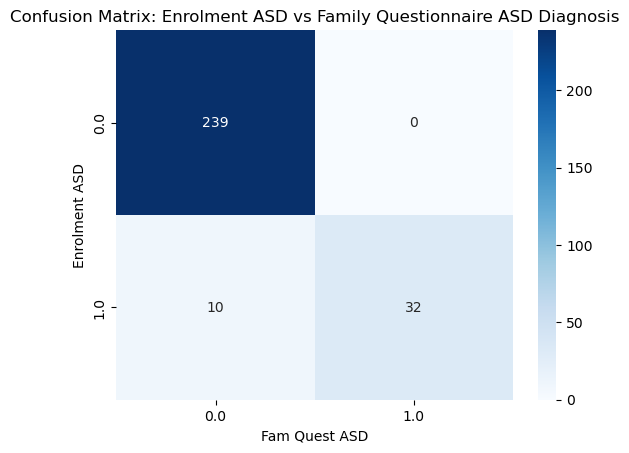

In [26]:
# Plot confusion matrix of enrolment vs matched ASD diagnosis
confusion_matrix = pd.crosstab(combined_diagnosis['enrol_asd'], combined_diagnosis['asd_psq'], rownames=['Enrolment ASD'], colnames=['Fam Quest ASD'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Enrolment ASD vs Family Questionnaire ASD Diagnosis')
plt.show()

In [27]:
# Create a new column that combines fills enrollment when nan using matched data
combined_diagnosis['asd'] = combined_diagnosis.apply(
    lambda row: row['enrol_asd'] if pd.notna(row['enrol_asd']) else row['asd_psq'], axis=1
)
# For those that have 1 in medical records ASD but 0 in enrolment ASD, fill enrolment ASD with 1
combined_diagnosis['asd'] = combined_diagnosis.apply(
    lambda row: 1 if (row['medical_records_asd'] == 1 and row['enrol_asd'] == 0) else row['asd'], axis=1
)
combined_diagnosis

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,asd_match,asd
0,Q1K_HSJ_100100_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,1.0
1,Q1K_HSJ_100100_S1,0.0,exact,0.0,1.0,0.0,0.0,1.0,1.0,0.0,match,0.0
2,Q1K_HSJ_100100_M1,0.0,high_confidence,0.0,1.0,NaN,1.0,0.0,0.0,0.0,match,0.0
3,Q1K_HSJ_100100_F1,0.0,high_confidence,0.0,1.0,0.0,1.0,1.0,0.0,0.0,match,0.0
4,Q1K_HSJ_100104_P,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1231,Q1K_HSJ_10093_O1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1232,Q1K_HSJ_10097_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,1.0
1233,Q1K_HSJ_10097_M1,0.0,high_confidence,0.0,0.0,NaN,0.0,0.0,0.0,0.0,match,0.0
1234,Q1K_HSJ_10097_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [28]:
# Convert ASD to 0 if participant is marked as 0 in the NDD column and asd is not already 1
combined_diagnosis['asd'] = combined_diagnosis.apply(
    lambda row: 0 if (row['ndd'] == 0 and row['asd'] != 1) else row['asd'], axis=1
)
combined_diagnosis

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,asd_match,asd
0,Q1K_HSJ_100100_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,1.0
1,Q1K_HSJ_100100_S1,0.0,exact,0.0,1.0,0.0,0.0,1.0,1.0,0.0,match,0.0
2,Q1K_HSJ_100100_M1,0.0,high_confidence,0.0,1.0,NaN,1.0,0.0,0.0,0.0,match,0.0
3,Q1K_HSJ_100100_F1,0.0,high_confidence,0.0,1.0,0.0,1.0,1.0,0.0,0.0,match,0.0
4,Q1K_HSJ_100104_P,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1231,Q1K_HSJ_10093_O1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1232,Q1K_HSJ_10097_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,1.0
1233,Q1K_HSJ_10097_M1,0.0,high_confidence,0.0,0.0,NaN,0.0,0.0,0.0,0.0,match,0.0
1234,Q1K_HSJ_10097_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [29]:
# Create subject ID
# Function to format ID so that they match BIDS
def q1k_to_BIDS(subject_id):
    if "HSJ" in subject_id:
        if "1025-" in subject_id:
            truncated_id=subject_id.split('1025')[1][1:]
        elif "1025-" in subject_id:
            truncated_id=subject_id.split('1025')[1][1:]
        elif "1525-" in subject_id:
            truncated_id=subject_id.split('1525')[1][1:]
        else:
            truncated_id=subject_id.split('Q1K_HSJ_100')[1]
    elif "MHC" in subject_id:
        if "2524-" in subject_id:
            truncated_id=subject_id.split('2524')[1][1:]
        elif "test" in subject_id:
            truncated_id=subject_id
        else:
            truncated_id=subject_id.split('Q1K_MHC_200')[1]
    elif "GAT" in subject_id:
        truncated_id=subject_id.split('6527')[1]
    elif "SHR" in subject_id:
         truncated_id=subject_id.split('5526')[1][1:]
    elif "OIM" in subject_id:
         truncated_id=subject_id.split('4529')[1][1:]
    elif "NIM" in subject_id:
         truncated_id=subject_id.split('3530')[1][1:]
    elif "test" in subject_id or "TEST" in subject_id:
        truncated_id=subject_id
    else:
        truncated_id=subject_id
    parts = truncated_id.split('_')
    if len(parts) == 2:
        numeric_part = parts[0]
        letter_part = parts[1]
        # Ensure numeric part is 4 digits long by padding with zeros if necessary
        padded_numeric_part = numeric_part.zfill(4)

        formatted_id = f"{padded_numeric_part}{letter_part}"
        formatted_id=formatted_id.strip()
    else: 
        print(f"Invalid ID format for sub {subject_id}. Should be 'XXX_XX' or 'XXXX_XX' or 'XXX_X' or 'XXXX_XX'.")
        formatted_id=subject_id
    return formatted_id
# Change q1k_ID to bids
combined_diagnosis["subject"]=np.nan
for subject_id in combined_diagnosis.q1k_ID.unique():
    new_id=q1k_to_BIDS(subject_id)

    print(subject_id, new_id)
    combined_diagnosis.loc[combined_diagnosis.q1k_ID==subject_id, "subject"]=new_id


Q1K_HSJ_100100_P 0100P
Q1K_HSJ_100100_S1 0100S1
Q1K_HSJ_100100_M1 0100M1
Q1K_HSJ_100100_F1 0100F1
Q1K_HSJ_100104_P 0104P
Q1K_HSJ_100105_P 0105P
Q1K_HSJ_100105_M1 0105M1
Q1K_HSJ_100105_F1 0105F1
Q1K_HSJ_100108_P 0108P
Q1K_HSJ_100108_M1 0108M1
Q1K_HSJ_100108_F1 0108F1
Q1K_HSJ_100111_P 0111P
Q1K_HSJ_100111_M1 0111M1
Q1K_HSJ_100111_F1 0111F1
Q1K_HSJ_100114_P 0114P
Q1K_HSJ_100114_S1 0114S1
Q1K_HSJ_100114_S2 0114S2
Q1K_HSJ_100114_M1 0114M1
Q1K_HSJ_100114_F1 0114F1
Q1K_HSJ_100119_P 0119P
Q1K_HSJ_100119_S1 0119S1
Q1K_HSJ_100119_M1 0119M1
Q1K_HSJ_100119_F1 0119F1
Q1K_HSJ_100123_P 0123P
Q1K_HSJ_100123_M1 0123M1
Q1K_HSJ_100123_F1 0123F1
Q1K_HSJ_100126_P 0126P
Q1K_HSJ_100126_M1 0126M1
Q1K_HSJ_100128_P 0128P
Q1K_HSJ_100129_P 0129P
Q1K_HSJ_100129_M1 0129M1
Q1K_HSJ_100131_P 0131P
Q1K_HSJ_100131_S1 0131S1
Q1K_HSJ_100131_M1 0131M1
Q1K_HSJ_100134_P 0134P
Q1K_HSJ_100134_S1 0134S1
Q1K_HSJ_100134_M1 0134M1
Q1K_HSJ_100134_F1 0134F1
Q1K_HSJ_100144_P 0144P
Q1K_HSJ_100144_M1 0144M1
Q1K_HSJ_100146_P 0146P
Q1K_H

C:\Users\gabot\AppData\Local\Temp\ipykernel_14512\2076707201.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0100P' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_diagnosis.loc[combined_diagnosis.q1k_ID==subject_id, "subject"]=new_id


Q1K_HSJ_1525-1447_F1 1447F1
Q1K_HSJ_1525-1447_S1 1447S1
Q1K_HSJ_1525-1447_S2 1447S2
Q1K_HSJ_1525-1452_P 1452P
Q1K_HSJ_1525-1452_M1 1452M1
Q1K_HSJ_1525-1452_F1 1452F1
Q1K_HSJ_1525-1452_S1 1452S1
Q1K_HSJ_1525-1456_P 1456P
Q1K_HSJ_1525-1456_M1 1456M1
Q1K_HSJ_1525-1458_P 1458P
Q1K_HSJ_1525-1458_M1 1458M1
Q1K_HSJ_1525-1458_S1 1458S1
Q1K_HSJ_1525-1461_P 1461P
Q1K_HSJ_1525-1461_F1 1461F1
Q1K_HSJ_1525-1463_P 1463P
Q1K_HSJ_1525-1463_M1 1463M1
Q1K_HSJ_1525-1463_F1 1463F1
Q1K_HSJ_1525-1466_P 1466P
Q1K_HSJ_1525-1466_M1 1466M1
Q1K_HSJ_1525-1468_P 1468P
Q1K_HSJ_1525-1468_M1 1468M1
Q1K_HSJ_1525-1458_S2 1458S2
Q1K_HSJ_1525-1471_P 1471P
Q1K_HSJ_1525-1471_M1 1471M1
Q1K_HSJ_1525-1474_P 1474P
Q1K_HSJ_1525-1475_P 1475P
Q1K_HSJ_1525-1475_M1 1475M1
Q1K_HSJ_1525-1468_F1 1468F1
Q1K_HSJ_1525-1478_P 1478P
Q1K_HSJ_1525-1478_M1 1478M1
Q1K_HSJ_1525-1478_F1 1478F1
Q1K_HSJ_1525-1481_P 1481P
Q1K_HSJ_1525-1481_M1 1481M1
Q1K_HSJ_1525-1483_P 1483P
Q1K_HSJ_1525-1483_M1 1483M1
Q1K_HSJ_1525-1483_F1 1483F1
Q1K_HSJ_1525-1483_

In [30]:
# Check how many have P in the subject ID, value count diagnosis and ndd
p_subjects = combined_diagnosis[combined_diagnosis['subject'].str.contains('P', na=False)]
p_subjects_count = p_subjects.shape[0]
p_subjects_diagnosis_count = p_subjects['asd'].value_counts()
p_subjects_ndd_count = p_subjects['ndd'].value_counts()

print(f"Subjects with 'P' in ID: {p_subjects_count}")
print(f"Subjects with diagnosis: {p_subjects_diagnosis_count}")
print(f"Subjects with NDD: {p_subjects_ndd_count}")

Subjects with 'P' in ID: 400
Subjects with diagnosis: asd
1.0    228
0.0    120
Name: count, dtype: int64
Subjects with NDD: ndd
1.0    399
0.0      1
Name: count, dtype: int64


In [31]:
asd_diagnosis_File = "C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/diagnosis/asd_diagnosis.csv"
combined_diagnosis.to_csv(asd_diagnosis_File, index=False)

In [32]:
combined_diagnosis

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,asd_match,asd,subject
0,Q1K_HSJ_100100_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,1.0,0100P
1,Q1K_HSJ_100100_S1,0.0,exact,0.0,1.0,0.0,0.0,1.0,1.0,0.0,match,0.0,0100S1
2,Q1K_HSJ_100100_M1,0.0,high_confidence,0.0,1.0,NaN,1.0,0.0,0.0,0.0,match,0.0,0100M1
3,Q1K_HSJ_100100_F1,0.0,high_confidence,0.0,1.0,0.0,1.0,1.0,0.0,0.0,match,0.0,0100F1
4,Q1K_HSJ_100104_P,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,0.0,0104P
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1231,Q1K_HSJ_10093_O1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0093O1
1232,Q1K_HSJ_10097_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,1.0,0097P
1233,Q1K_HSJ_10097_M1,0.0,high_confidence,0.0,0.0,NaN,0.0,0.0,0.0,0.0,match,0.0,0097M1
1234,Q1K_HSJ_10097_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0097F1


### Confirm diagnosis using SRS and SCQ

#### SRS

In [44]:
# Based on glob find all files that have SRS label in the name  
srs_files = glob.glob(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/clinical/srs*.csv')
srs_df= pd.read_csv(srs_files[0])

In [45]:
# Merge SRS and Diagnosis
srs_diag=combined_diagnosis.merge(srs_df, left_on='q1k_ID', right_on="q1k_id", how='left')

In [46]:
# Check how many individuals with an ASD diagnosis had scores higher than 75 (clinical range)
srs_confirm=srs_diag.dropna(subset="tscore_total")
clinical_srs_counts = len(srs_confirm[(srs_confirm['asd'] == 1) & (srs_confirm['tscore_total'] >=60)])
total_records=len(srs_confirm[(srs_confirm['asd'] == 1) & (srs_confirm['tscore_total'] <=60)])
print("Total SRS clinical range and ASD diagnosis: ", (clinical_srs_counts/(total_records + clinical_srs_counts))*100)

Total SRS clinical range and ASD diagnosis:  87.73234200743495


#### SCQ

In [50]:
# Based on glob find all files that have SRS label in the name  
scq_files = glob.glob(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/clinical/scq*.csv')
scq_df= pd.read_csv(scq_files[0])
# Drop record id
scq_df = scq_df.drop(columns=['record_id'])

In [51]:
# Merge SRS and Diagnosis
full_clinical=srs_diag.merge(scq_df, on='q1k_ID', how='left')

In [52]:
full_clinical

,q1k_ID,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,adhd,learning_disability,language_communication_disorder,motor_disorder,...,tscore_total,scq_age,scq_1,SCQ_A,SCQ_B,RRB_Dom,SCQ_Range,SocInt_Dom,Comm_Dom,total_nas
0,Q1K_HSJ_100100_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,61.0,6.508119,1.0,27.0,NaN,2.0,clinical,14.0,9.0,1.0
1,Q1K_HSJ_100100_S1,0.0,exact,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,51.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Q1K_HSJ_100100_M1,0.0,high_confidence,0.0,1.0,NaN,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Q1K_HSJ_100100_F1,0.0,high_confidence,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,57.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q1K_HSJ_100104_P,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1231,Q1K_HSJ_10093_O1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1232,Q1K_HSJ_10097_P,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,90.0,7.978261,0.0,NaN,14.0,6.0,NaN,5.0,1.0,1.0
1233,Q1K_HSJ_10097_M1,0.0,high_confidence,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,46.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1234,Q1K_HSJ_10097_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Check how many individuals with an ASD diagnosis had scores higher than 75 (clinical range)
scq_confirm=full_clinical.dropna(subset="SCQ_Range")
clinical_s_confirm_counts = len(scq_confirm[(scq_confirm['asd'] == 1) & (scq_confirm['SCQ_Range']=="clinical")])
total_records=len(scq_confirm[(scq_confirm['asd'] == 1) & (scq_confirm['SCQ_Range']=="normal")])
print("Total SCQ clinical range and ASD diagnosis: ", (clinical_s_confirm_counts/(total_records + clinical_s_confirm_counts))*100)

Total SCQ clinical range and ASD diagnosis:  74.73118279569893


In [54]:
# Save the merged dataframe 
full_clinical.to_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/clinical/full_clinical.csv", index=False)